## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully!")

All libraries imported successfully!


## Load data

In [2]:
print("Loading creditcard.csv dataset...")
df = pd.read_csv('../Dataset/creditcard.csv') 

print(f"\nDataset shape: {df.shape}")

print(f"\nFirst few rows:")
print(df.head())

print(f"\nDataset info:")
print(df.info())

print(f"\nClass distribution (0: Normal, 1: Fraud):")
print(df['Class'].value_counts())
print(f"\nFraud percentage: {df['Class'].mean() * 100:.4f}%")

Loading creditcard.csv dataset...

Dataset shape: (284807, 31)

First few rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009

## Prepare features and target

In [3]:
X = df.drop('Class', axis=1)
y = df['Class']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (284807, 30)
Target shape: (284807,)


### Define Evaluation Function

In [4]:
def evaluate_model(y_true, y_pred, y_pred_proba=None):
    """Calculate precision, recall, f1, and AUC for model evaluation"""
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    metrics = {
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }
    
    if y_pred_proba is not None:
        auc = roc_auc_score(y_true, y_pred_proba)
        metrics['AUC-ROC'] = auc
    
    return metrics

def print_metrics(metrics, model_name=""):
    """Pretty print metrics"""
    if model_name:
        print(f"\n📊 {model_name}:")
    print(f"  Precision: {metrics['Precision']:.4f}")
    print(f"  Recall:    {metrics['Recall']:.4f}")
    print(f"  F1-Score:  {metrics['F1-Score']:.4f}")
    if 'AUC-ROC' in metrics:
        print(f"  AUC-ROC:   {metrics['AUC-ROC']:.4f}")

## Demonstrate DIFFERENT types of data leakage

### LEAKAGE 1 - Scaling before splitting (using full dataset statistics)

In [5]:
print("\n" + "="*80)
print("🔴 LEAKAGE TYPE 1: Scaling before train-test split")
print("="*80)

# Define classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=50, max_depth=5),
}

# Leaky approach: Scale the entire dataset before splitting
scaler_leaky = StandardScaler()
X_scaled_leaky = scaler_leaky.fit_transform(X)
X_train_leaky, X_test_leaky, y_train_leaky, y_test_leaky = train_test_split(
    X_scaled_leaky, y, test_size=0.3, random_state=42, stratify=y
)

# Correct approach: Scale after splitting
X_train_correct, X_test_correct, y_train_correct, y_test_correct = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
scaler_correct = StandardScaler()
X_train_correct_scaled = scaler_correct.fit_transform(X_train_correct)
X_test_correct_scaled = scaler_correct.transform(X_test_correct)

# Store results
results_leaky_scaling = {name: {} for name in classifiers.keys()}
results_correct_scaling = {name: {} for name in classifiers.keys()}

# Train and evaluate with leaky scaling
print("\n❌ With LEAKY scaling (using full dataset statistics):")
print("-" * 60)
for name, clf in classifiers.items():
    clf.fit(X_train_leaky, y_train_leaky)
    y_pred = clf.predict(X_test_leaky)
    y_pred_proba = clf.predict_proba(X_test_leaky)[:, 1] if hasattr(clf, "predict_proba") else None
    
    metrics = evaluate_model(y_test_leaky, y_pred, y_pred_proba)
    results_leaky_scaling[name] = metrics
    print_metrics(metrics, name)

# Train and evaluate with correct scaling
print("\n✅ With CORRECT scaling (fit on train only):")
print("-" * 60)
for name, clf in classifiers.items():
    clf.fit(X_train_correct_scaled, y_train_correct)
    y_pred = clf.predict(X_test_correct_scaled)
    y_pred_proba = clf.predict_proba(X_test_correct_scaled)[:, 1] if hasattr(clf, "predict_proba") else None
    
    metrics = evaluate_model(y_test_correct, y_pred, y_pred_proba)
    results_correct_scaling[name] = metrics
    print_metrics(metrics, name)


🔴 LEAKAGE TYPE 1: Scaling before train-test split

❌ With LEAKY scaling (using full dataset statistics):
------------------------------------------------------------

📊 Logistic Regression:
  Precision: 0.8476
  Recall:    0.6014
  F1-Score:  0.7036
  AUC-ROC:   0.9575

📊 Decision Tree:
  Precision: 0.9098
  Recall:    0.7500
  F1-Score:  0.8222
  AUC-ROC:   0.8816

📊 Random Forest:
  Precision: 0.9298
  Recall:    0.7162
  F1-Score:  0.8092
  AUC-ROC:   0.9557

✅ With CORRECT scaling (fit on train only):
------------------------------------------------------------

📊 Logistic Regression:
  Precision: 0.8505
  Recall:    0.6149
  F1-Score:  0.7137
  AUC-ROC:   0.9567

📊 Decision Tree:
  Precision: 0.9098
  Recall:    0.7500
  F1-Score:  0.8222
  AUC-ROC:   0.8816

📊 Random Forest:
  Precision: 0.9298
  Recall:    0.7162
  F1-Score:  0.8092
  AUC-ROC:   0.9557


#### Visualize scaling leakage impact

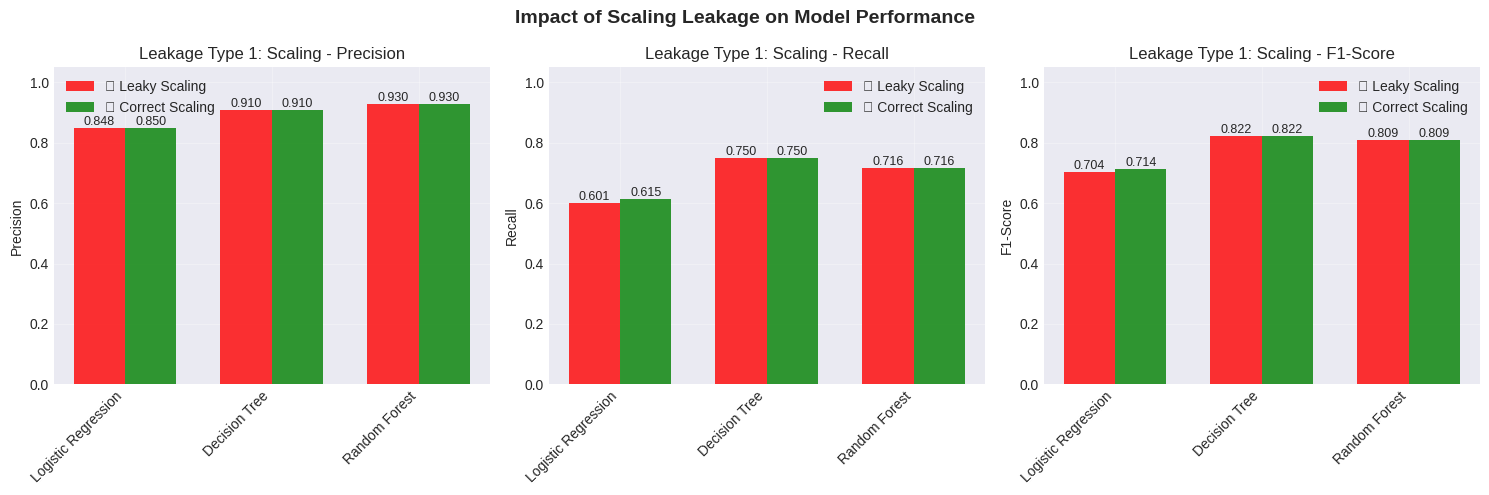

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_to_plot = ['Precision', 'Recall', 'F1-Score']
for idx, metric in enumerate(metrics_to_plot):
    x_pos = np.arange(len(classifiers))
    width = 0.35
    
    leaky_scores = [results_leaky_scaling[name][metric] for name in classifiers.keys()]
    correct_scores = [results_correct_scaling[name][metric] for name in classifiers.keys()]
    
    bars1 = axes[idx].bar(x_pos - width/2, leaky_scores, width, label='❌ Leaky Scaling', alpha=0.8, color='red')
    bars2 = axes[idx].bar(x_pos + width/2, correct_scores, width, label='✅ Correct Scaling', alpha=0.8, color='green')
    
    axes[idx].set_ylabel(metric)
    axes[idx].set_title(f'Leakage Type 1: Scaling - {metric}')
    axes[idx].set_xticks(x_pos)
    axes[idx].set_xticklabels(classifiers.keys(), rotation=45, ha='right')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim([0, 1.05])
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                          f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Impact of Scaling Leakage on Model Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### LEAKAGE 2 - Using future information (target leakage)

In [7]:
print("\n" + "="*80)
print("🔴 LEAKAGE 2: Target Leakage (using future information)")
print("="*80)

# Create synthetic features that leak information from the target
df_with_leakage = df.copy()
# Feature 1: Direct target leakage with noise
df_with_leakage['leaky_feature_1'] = df_with_leakage['Class'] + np.random.normal(0, 0.1, len(df))
# Feature 2: Target multiplied by existing feature (information leakage)
df_with_leakage['leaky_feature_2'] = df_with_leakage['Class'] * df_with_leakage['V1'] + np.random.normal(0, 0.05, len(df))
# Feature 3: Statistical leakage (mean of target by group - would not be available in production)
df_with_leakage['leaky_feature_3'] = df_with_leakage.groupby(df_with_leakage.index // 1000)['Class'].transform('mean').fillna(0)

print("Created 3 leaky features that wouldn't be available at prediction time!")

X_leaky = df_with_leakage.drop('Class', axis=1)
y_leaky = df_with_leakage['Class']

# Split data
X_train_target, X_test_target, y_train_target, y_test_target = train_test_split(
    X_leaky, y_leaky, test_size=0.3, random_state=42, stratify=y_leaky
)

# Scale properly
scaler_target = StandardScaler()
X_train_target_scaled = scaler_target.fit_transform(X_train_target)
X_test_target_scaled = scaler_target.transform(X_test_target)

# Clean version without leaky features
X_clean = df.drop('Class', axis=1)
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y, test_size=0.3, random_state=42, stratify=y
)
scaler_clean = StandardScaler()
X_train_clean_scaled = scaler_clean.fit_transform(X_train_clean)
X_test_clean_scaled = scaler_clean.transform(X_test_clean)

# Store results
results_target_leakage = {name: {} for name in classifiers.keys()}
results_no_leakage = {name: {} for name in classifiers.keys()}

print("\n❌ With TARGET LEAKAGE (including features that wouldn't be available):")
print("-" * 60)
for name, clf in classifiers.items():
    clf.fit(X_train_target_scaled, y_train_target)
    y_pred = clf.predict(X_test_target_scaled)
    y_pred_proba = clf.predict_proba(X_test_target_scaled)[:, 1] if hasattr(clf, "predict_proba") else None
    
    metrics = evaluate_model(y_test_target, y_pred, y_pred_proba)
    results_target_leakage[name] = metrics
    print_metrics(metrics, name)

print("\n✅ Without target leakage (clean features only):")
print("-" * 60)
for name, clf in classifiers.items():
    clf.fit(X_train_clean_scaled, y_train_clean)
    y_pred = clf.predict(X_test_clean_scaled)
    y_pred_proba = clf.predict_proba(X_test_clean_scaled)[:, 1] if hasattr(clf, "predict_proba") else None
    
    metrics = evaluate_model(y_test_clean, y_pred, y_pred_proba)
    results_no_leakage[name] = metrics
    print_metrics(metrics, name)


🔴 LEAKAGE 2: Target Leakage (using future information)
Created 3 leaky features that wouldn't be available at prediction time!

❌ With TARGET LEAKAGE (including features that wouldn't be available):
------------------------------------------------------------

📊 Logistic Regression:
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  AUC-ROC:   1.0000

📊 Decision Tree:
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  AUC-ROC:   1.0000

📊 Random Forest:
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  AUC-ROC:   1.0000

✅ Without target leakage (clean features only):
------------------------------------------------------------

📊 Logistic Regression:
  Precision: 0.8505
  Recall:    0.6149
  F1-Score:  0.7137
  AUC-ROC:   0.9567

📊 Decision Tree:
  Precision: 0.9098
  Recall:    0.7500
  F1-Score:  0.8222
  AUC-ROC:   0.8816

📊 Random Forest:
  Precision: 0.9298
  Recall:    0.7162
  F1-Score:  0.8092
  AUC-ROC:   0.9557


#### Visualize Target Leakage Impact

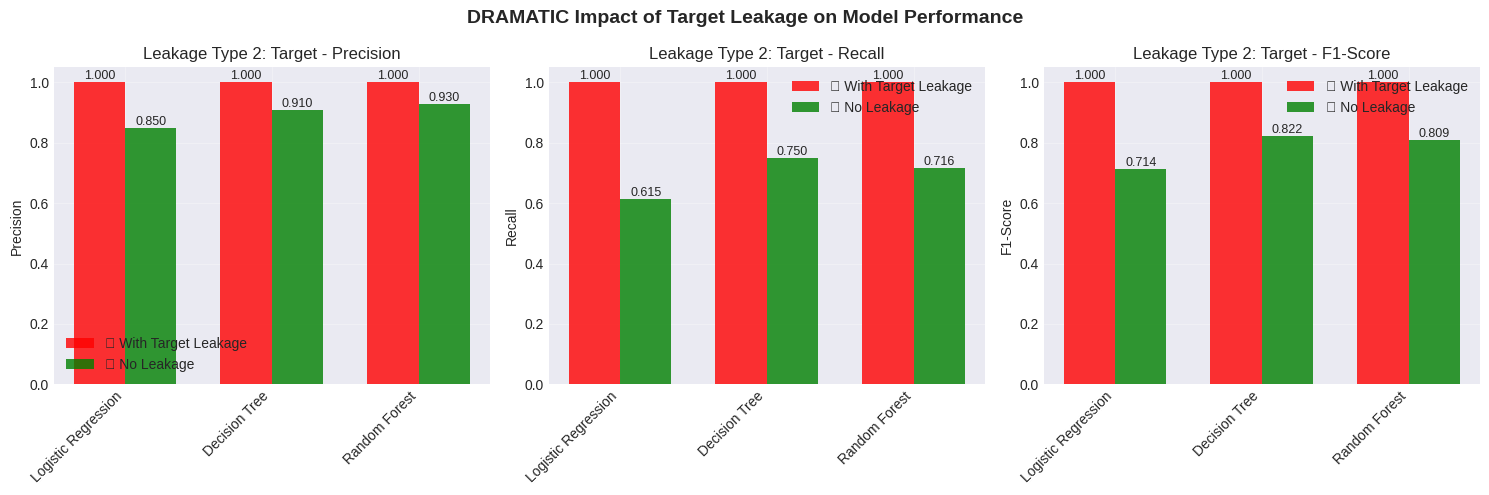

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, metric in enumerate(['Precision', 'Recall', 'F1-Score']):
    x_pos = np.arange(len(classifiers))
    width = 0.35
    
    leaky_scores = [results_target_leakage[name][metric] for name in classifiers.keys()]
    clean_scores = [results_no_leakage[name][metric] for name in classifiers.keys()]
    
    bars1 = axes[idx].bar(x_pos - width/2, leaky_scores, width, label='❌ With Target Leakage', alpha=0.8, color='red')
    bars2 = axes[idx].bar(x_pos + width/2, clean_scores, width, label='✅ No Leakage', alpha=0.8, color='green')
    
    axes[idx].set_ylabel(metric)
    axes[idx].set_title(f'Leakage Type 2: Target - {metric}')
    axes[idx].set_xticks(x_pos)
    axes[idx].set_xticklabels(classifiers.keys(), rotation=45, ha='right')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim([0, 1.05])
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                          f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('DRAMATIC Impact of Target Leakage on Model Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### LEAKAGE 3 - CROSS-VALIDATION LEAKAGE

In [9]:
print("\n" + "="*80)
print("🔴 LEAKAGE TYPE 3: Preprocessing before Cross-Validation")
print("="*80)

# Leaky CV approach: Preprocess entire dataset before CV
print("\n❌ LEAKY Cross-Validation (preprocessing all data first):")
print("-" * 60)

cv_results_leaky = {name: {'Precision': [], 'Recall': [], 'F1-Score': []} for name in classifiers.keys()}

X_scaled_full = StandardScaler().fit_transform(X)

for name, clf in classifiers.items():
    # Use cross_validate to get multiple metrics
    scores = cross_validate(clf, X_scaled_full, y, cv=5, 
                           scoring=['precision', 'recall', 'f1'])
    
    cv_results_leaky[name]['Precision'] = scores['test_precision'].mean()
    cv_results_leaky[name]['Recall'] = scores['test_recall'].mean()
    cv_results_leaky[name]['F1-Score'] = scores['test_f1'].mean()
    
    print(f"\n{name}:")
    print(f"  Precision: {cv_results_leaky[name]['Precision']:.4f} (+/- {scores['test_precision'].std() * 2:.4f})")
    print(f"  Recall:    {cv_results_leaky[name]['Recall']:.4f} (+/- {scores['test_recall'].std() * 2:.4f})")
    print(f"  F1-Score:  {cv_results_leaky[name]['F1-Score']:.4f} (+/- {scores['test_f1'].std() * 2:.4f})")

# Correct CV approach: Use pipeline to prevent leakage
print("\n✅ CORRECT Cross-Validation (preprocessing inside CV folds):")
print("-" * 60)

cv_results_correct = {name: {'Precision': [], 'Recall': [], 'F1-Score': []} for name in classifiers.keys()}

for name, clf in classifiers.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', clf)
    ])
    
    scores = cross_validate(pipeline, X, y, cv=5,
                           scoring=['precision', 'recall', 'f1'])
    
    cv_results_correct[name]['Precision'] = scores['test_precision'].mean()
    cv_results_correct[name]['Recall'] = scores['test_recall'].mean()
    cv_results_correct[name]['F1-Score'] = scores['test_f1'].mean()
    
    print(f"\n{name}:")
    print(f"  Precision: {cv_results_correct[name]['Precision']:.4f} (+/- {scores['test_precision'].std() * 2:.4f})")
    print(f"  Recall:    {cv_results_correct[name]['Recall']:.4f} (+/- {scores['test_recall'].std() * 2:.4f})")
    print(f"  F1-Score:  {cv_results_correct[name]['F1-Score']:.4f} (+/- {scores['test_f1'].std() * 2:.4f})")


🔴 LEAKAGE TYPE 3: Preprocessing before Cross-Validation

❌ LEAKY Cross-Validation (preprocessing all data first):
------------------------------------------------------------

Logistic Regression:
  Precision: 0.8835 (+/- 0.1807)
  Recall:    0.6174 (+/- 0.3067)
  F1-Score:  0.7076 (+/- 0.1669)

Decision Tree:
  Precision: 0.7336 (+/- 0.7421)
  Recall:    0.7619 (+/- 0.1742)
  F1-Score:  0.6443 (+/- 0.6428)

Random Forest:
  Precision: 0.7614 (+/- 0.7720)
  Recall:    0.7495 (+/- 0.2920)
  F1-Score:  0.6363 (+/- 0.6453)

✅ CORRECT Cross-Validation (preprocessing inside CV folds):
------------------------------------------------------------

Logistic Regression:
  Precision: 0.8774 (+/- 0.1870)
  Recall:    0.6113 (+/- 0.2936)
  F1-Score:  0.7023 (+/- 0.1626)

Decision Tree:
  Precision: 0.7336 (+/- 0.7421)
  Recall:    0.7619 (+/- 0.1742)
  F1-Score:  0.6443 (+/- 0.6428)

Random Forest:
  Precision: 0.7614 (+/- 0.7720)
  Recall:    0.7495 (+/- 0.2920)
  F1-Score:  0.6363 (+/- 0.6453)


#### Visualize Cross-Validation Leakage Impact

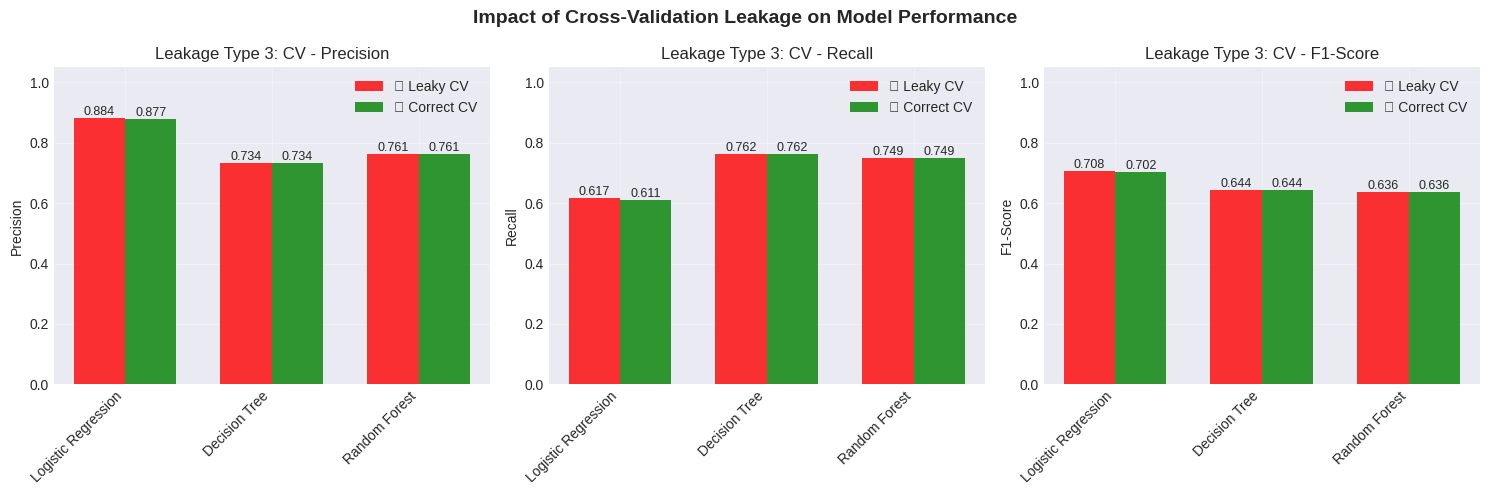

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, metric in enumerate(['Precision', 'Recall', 'F1-Score']):
    x_pos = np.arange(len(classifiers))
    width = 0.35
    
    leaky_scores = [cv_results_leaky[name][metric] for name in classifiers.keys()]
    correct_scores = [cv_results_correct[name][metric] for name in classifiers.keys()]
    
    bars1 = axes[idx].bar(x_pos - width/2, leaky_scores, width, label='❌ Leaky CV', alpha=0.8, color='red')
    bars2 = axes[idx].bar(x_pos + width/2, correct_scores, width, label='✅ Correct CV', alpha=0.8, color='green')
    
    axes[idx].set_ylabel(metric)
    axes[idx].set_title(f'Leakage Type 3: CV - {metric}')
    axes[idx].set_xticks(x_pos)
    axes[idx].set_xticklabels(classifiers.keys(), rotation=45, ha='right')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim([0, 1.05])
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                          f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Impact of Cross-Validation Leakage on Model Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### LEAKAGE 4 - SAMPLING LEAKAGE (RUS & SMOTE)

##### Split data for sampling experiments (clean split first!)

In [11]:
print("\n" + "="*80)
print("🔴 LEAKAGE TYPE 4: Sampling Leakage (RandomUnderSampler & SMOTE)")
print("="*80)

# IMPORTANT: Split FIRST before any sampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"✅ Data split correctly first!")
print(f"Training set shape: {X_train.shape}")
print(f"Training class distribution:\n{y_train.value_counts()}")
print(f"Test set shape: {X_test.shape}")
print(f"Test class distribution:\n{y_test.value_counts()}")

# Scale the data (correctly - fit on train only)
scaler_sampling = StandardScaler()
X_train_scaled = scaler_sampling.fit_transform(X_train)
X_test_scaled = scaler_sampling.transform(X_test)


🔴 LEAKAGE TYPE 4: Sampling Leakage (RandomUnderSampler & SMOTE)
✅ Data split correctly first!
Training set shape: (199364, 30)
Training class distribution:
Class
0    199020
1       344
Name: count, dtype: int64
Test set shape: (85443, 30)
Test class distribution:
Class
0    85295
1      148
Name: count, dtype: int64


###### LEAKY SAMPLING - Apply sampling BEFORE train-test split

In [12]:
print("\n" + "="*50)
print("❌ LEAKY SAMPLING: Applying sampling on FULL dataset before split")
print("="*50)

# Leaky Random Under Sampling
rus_leaky_full = RandomUnderSampler(random_state=42)
X_rus_sampled, y_rus_sampled = rus_leaky_full.fit_resample(X, y)

# Leaky SMOTE
smote_leaky_full = SMOTE(random_state=42)
X_smote_sampled, y_smote_sampled = smote_leaky_full.fit_resample(X, y)

# Now split the already-sampled data (THIS IS LEAKY!)
X_train_rus_leaky, X_test_rus_leaky, y_train_rus_leaky, y_test_rus_leaky = train_test_split(
    X_rus_sampled, y_rus_sampled, test_size=0.3, random_state=42, stratify=y_rus_sampled
)

X_train_smote_leaky, X_test_smote_leaky, y_train_smote_leaky, y_test_smote_leaky = train_test_split(
    X_smote_sampled, y_smote_sampled, test_size=0.3, random_state=42, stratify=y_smote_sampled
)

# Scale (additional leakage!)
scaler_rus_leaky = StandardScaler()
X_train_rus_leaky = scaler_rus_leaky.fit_transform(X_train_rus_leaky)
X_test_rus_leaky = scaler_rus_leaky.transform(X_test_rus_leaky)

scaler_smote_leaky = StandardScaler()
X_train_smote_leaky = scaler_smote_leaky.fit_transform(X_train_smote_leaky)
X_test_smote_leaky = scaler_smote_leaky.transform(X_test_smote_leaky)

# Train and evaluate leaky RUS
results_rus_leaky = {}
print("\n📊 Results with LEAKY Random Under Sampling:")
print("-" * 60)
for name, clf in classifiers.items():
    if name != 'SVM':  # Skip SVM for speed
        clf.fit(X_train_rus_leaky, y_train_rus_leaky)
        y_pred = clf.predict(X_test_rus_leaky)
        y_pred_proba = clf.predict_proba(X_test_rus_leaky)[:, 1] if hasattr(clf, "predict_proba") else None
        
        metrics = evaluate_model(y_test_rus_leaky, y_pred, y_pred_proba)
        results_rus_leaky[name] = metrics
        print_metrics(metrics, name)

# Train and evaluate leaky SMOTE
results_smote_leaky = {}
print("\n📊 Results with LEAKY SMOTE:")
print("-" * 60)
for name, clf in classifiers.items():
    if name != 'SVM':  # Skip SVM for speed
        clf.fit(X_train_smote_leaky, y_train_smote_leaky)
        y_pred = clf.predict(X_test_smote_leaky)
        y_pred_proba = clf.predict_proba(X_test_smote_leaky)[:, 1] if hasattr(clf, "predict_proba") else None
        
        metrics = evaluate_model(y_test_smote_leaky, y_pred, y_pred_proba)
        results_smote_leaky[name] = metrics
        print_metrics(metrics, name)


❌ LEAKY SAMPLING: Applying sampling on FULL dataset before split

📊 Results with LEAKY Random Under Sampling:
------------------------------------------------------------

📊 Logistic Regression:
  Precision: 0.9855
  Recall:    0.9189
  F1-Score:  0.9510
  AUC-ROC:   0.9795

📊 Decision Tree:
  Precision: 0.9429
  Recall:    0.8919
  F1-Score:  0.9167
  AUC-ROC:   0.9331

📊 Random Forest:
  Precision: 0.9926
  Recall:    0.9054
  F1-Score:  0.9470
  AUC-ROC:   0.9846

📊 Results with LEAKY SMOTE:
------------------------------------------------------------

📊 Logistic Regression:
  Precision: 0.9910
  Recall:    0.9692
  F1-Score:  0.9800
  AUC-ROC:   0.9974

📊 Decision Tree:
  Precision: 0.9817
  Recall:    0.9581
  F1-Score:  0.9698
  AUC-ROC:   0.9898

📊 Random Forest:
  Precision: 0.9940
  Recall:    0.9446
  F1-Score:  0.9686
  AUC-ROC:   0.9953


##### Demonstrate Correct Sampling (Only on Training Data)

In [13]:
print("\n" + "="*50)
print("✅ CORRECT SAMPLING: Applying sampling ONLY on training data")
print("="*50)

# Baseline (no sampling, just scaled data)
results_baseline = {}
print("\n📊 BASELINE (No sampling, just scaling):")
print("-" * 60)
for name, clf in classifiers.items():
    if name != 'SVM':  # Skip SVM for speed
        clf.fit(X_train_scaled, y_train)
        y_pred = clf.predict(X_test_scaled)
        y_pred_proba = clf.predict_proba(X_test_scaled)[:, 1] if hasattr(clf, "predict_proba") else None
        
        metrics = evaluate_model(y_test, y_pred, y_pred_proba)
        results_baseline[name] = metrics
        print_metrics(metrics, name)

# Correct Random Under Sampling (on training data only)
rus_correct = RandomUnderSampler(random_state=42)
X_train_rus_correct, y_train_rus_correct = rus_correct.fit_resample(X_train_scaled, y_train)

results_rus_correct = {}
print("\n📊 CORRECT Random Under Sampling (on training data only):")
print("-" * 60)
for name, clf in classifiers.items():
    if name != 'SVM':  # Skip SVM for speed
        clf.fit(X_train_rus_correct, y_train_rus_correct)
        y_pred = clf.predict(X_test_scaled)
        y_pred_proba = clf.predict_proba(X_test_scaled)[:, 1] if hasattr(clf, "predict_proba") else None
        
        metrics = evaluate_model(y_test, y_pred, y_pred_proba)
        results_rus_correct[name] = metrics
        print_metrics(metrics, name)

# Correct SMOTE (on training data only)
smote_correct = SMOTE(random_state=42)
X_train_smote_correct, y_train_smote_correct = smote_correct.fit_resample(X_train_scaled, y_train)

results_smote_correct = {}
print("\n📊 CORRECT SMOTE (on training data only):")
print("-" * 60)
for name, clf in classifiers.items():
    if name != 'SVM':  # Skip SVM for speed
        clf.fit(X_train_smote_correct, y_train_smote_correct)
        y_pred = clf.predict(X_test_scaled)
        y_pred_proba = clf.predict_proba(X_test_scaled)[:, 1] if hasattr(clf, "predict_proba") else None
        
        metrics = evaluate_model(y_test, y_pred, y_pred_proba)
        results_smote_correct[name] = metrics
        print_metrics(metrics, name)


✅ CORRECT SAMPLING: Applying sampling ONLY on training data

📊 BASELINE (No sampling, just scaling):
------------------------------------------------------------

📊 Logistic Regression:
  Precision: 0.8505
  Recall:    0.6149
  F1-Score:  0.7137
  AUC-ROC:   0.9567

📊 Decision Tree:
  Precision: 0.9098
  Recall:    0.7500
  F1-Score:  0.8222
  AUC-ROC:   0.8816

📊 Random Forest:
  Precision: 0.9298
  Recall:    0.7162
  F1-Score:  0.8092
  AUC-ROC:   0.9557

📊 CORRECT Random Under Sampling (on training data only):
------------------------------------------------------------

📊 Logistic Regression:
  Precision: 0.0641
  Recall:    0.8851
  F1-Score:  0.1195
  AUC-ROC:   0.9714

📊 Decision Tree:
  Precision: 0.0135
  Recall:    0.8986
  F1-Score:  0.0266
  AUC-ROC:   0.9077

📊 Random Forest:
  Precision: 0.0965
  Recall:    0.8446
  F1-Score:  0.1731
  AUC-ROC:   0.9659

📊 CORRECT SMOTE (on training data only):
------------------------------------------------------------

📊 Logistic Reg

#### Visualize Sampling Leakage Impact

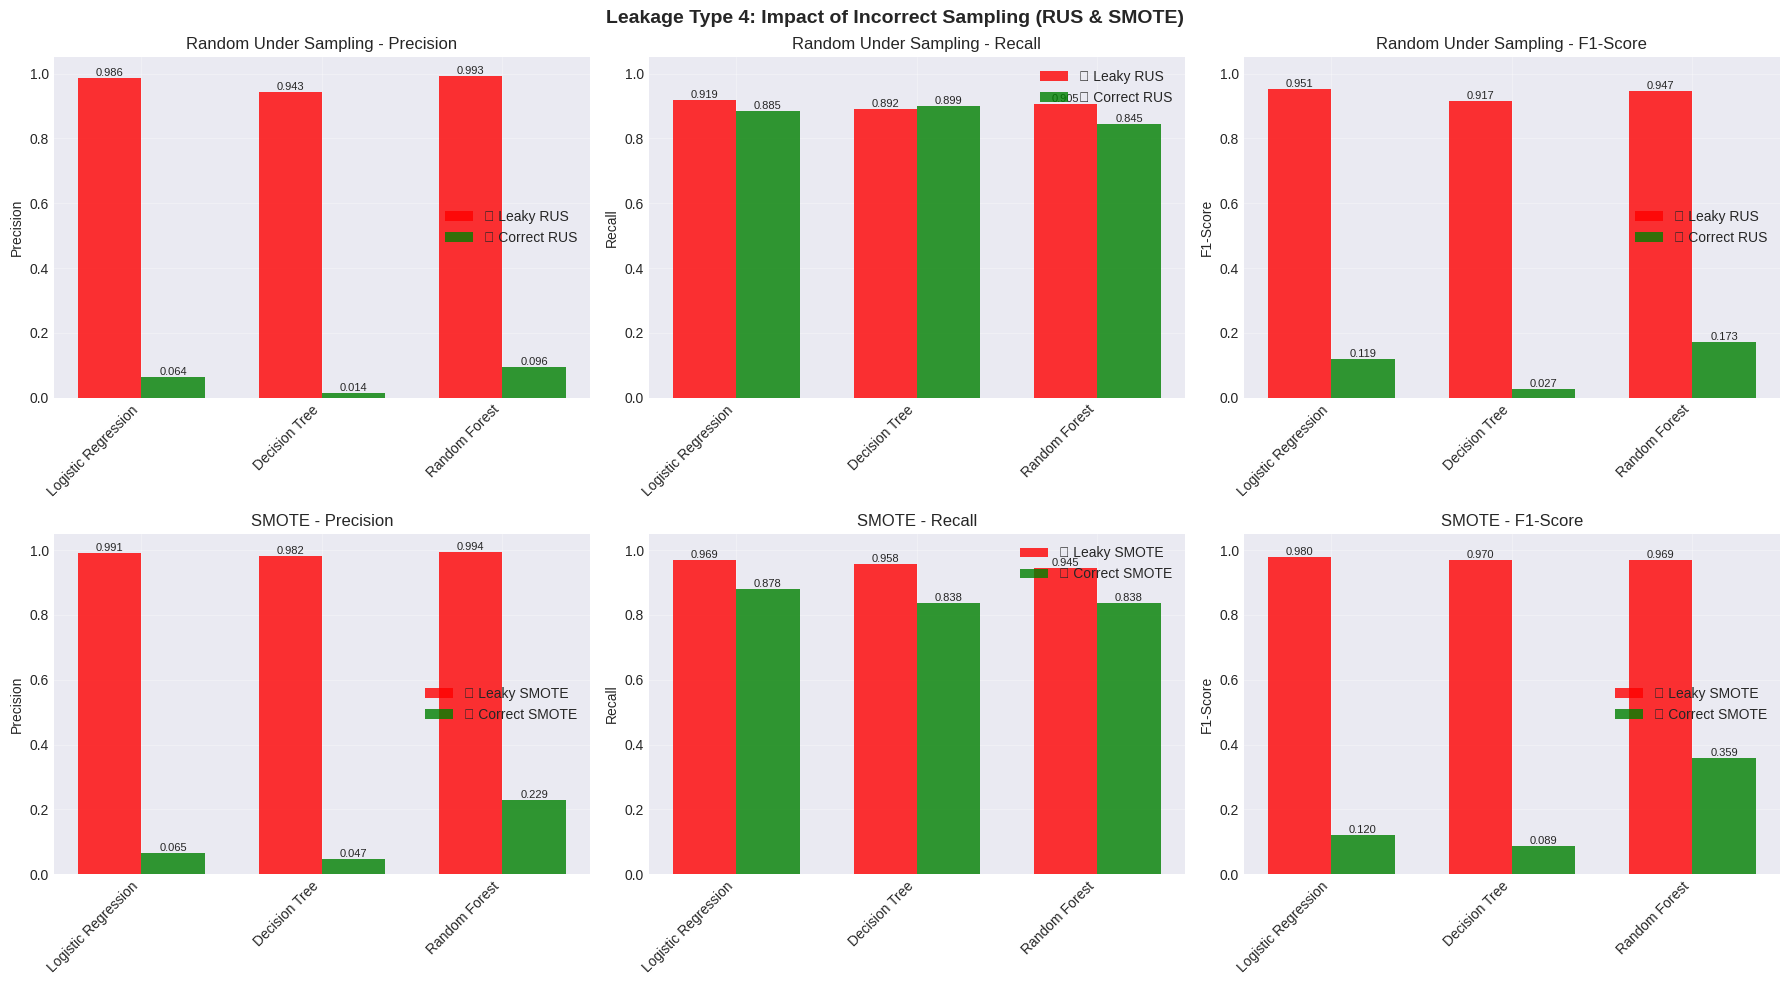

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics_to_plot = ['Precision', 'Recall', 'F1-Score']

# Plot for Random Under Sampling
for idx, metric in enumerate(metrics_to_plot):
    x_pos = np.arange(len([c for c in classifiers.keys() if c != 'SVM']))
    width = 0.35
    
    classifier_names = [c for c in classifiers.keys() if c != 'SVM']
    leaky_scores = [results_rus_leaky[name][metric] for name in classifier_names]
    correct_scores = [results_rus_correct[name][metric] for name in classifier_names]
    
    bars1 = axes[0, idx].bar(x_pos - width/2, leaky_scores, width, label='❌ Leaky RUS', alpha=0.8, color='red')
    bars2 = axes[0, idx].bar(x_pos + width/2, correct_scores, width, label='✅ Correct RUS', alpha=0.8, color='green')
    
    axes[0, idx].set_ylabel(metric)
    axes[0, idx].set_title(f'Random Under Sampling - {metric}')
    axes[0, idx].set_xticks(x_pos)
    axes[0, idx].set_xticklabels(classifier_names, rotation=45, ha='right')
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)
    axes[0, idx].set_ylim([0, 1.05])
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            axes[0, idx].text(bar.get_x() + bar.get_width()/2., height,
                            f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# Plot for SMOTE
for idx, metric in enumerate(metrics_to_plot):
    x_pos = np.arange(len([c for c in classifiers.keys() if c != 'SVM']))
    width = 0.35
    
    classifier_names = [c for c in classifiers.keys() if c != 'SVM']
    leaky_scores = [results_smote_leaky[name][metric] for name in classifier_names]
    correct_scores = [results_smote_correct[name][metric] for name in classifier_names]
    
    bars1 = axes[1, idx].bar(x_pos - width/2, leaky_scores, width, label='❌ Leaky SMOTE', alpha=0.8, color='red')
    bars2 = axes[1, idx].bar(x_pos + width/2, correct_scores, width, label='✅ Correct SMOTE', alpha=0.8, color='green')
    
    axes[1, idx].set_ylabel(metric)
    axes[1, idx].set_title(f'SMOTE - {metric}')
    axes[1, idx].set_xticks(x_pos)
    axes[1, idx].set_xticklabels(classifier_names, rotation=45, ha='right')
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)
    axes[1, idx].set_ylim([0, 1.05])
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            axes[1, idx].text(bar.get_x() + bar.get_width()/2., height,
                            f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Leakage Type 4: Impact of Incorrect Sampling (RUS & SMOTE)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### COMPLETE COMPARISON OF ALL 4 LEAKAGE TYPES

In [15]:
print("\n" + "="*80)
print("📊 COMPARING ALL FOUR LEAKAGE TYPES (F1-Score)")
print("="*80)

# Compile F1-scores for comparison
comparison_data = []
for name in [c for c in classifiers.keys() if c != 'SVM']:
    row = {
        'Classifier': name,
        'No Leakage': results_correct_scaling[name]['F1-Score'],
        'Scaling Leakage': results_leaky_scaling[name]['F1-Score'],
        'Target Leakage': results_target_leakage[name]['F1-Score'],
        'RUS Leakage': results_rus_leaky[name]['F1-Score'],
        'SMOTE Leakage': results_smote_leaky[name]['F1-Score']
    }
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
print("\n", comparison_df.to_string(index=False))

# Calculate the inflation caused by each leakage type
print("\n📈 PERFORMANCE INFLATION COMPARED TO NO LEAKAGE:")
for name in [c for c in classifiers.keys() if c != 'SVM']:
    print(f"\n{name}:")
    baseline = results_correct_scaling[name]['F1-Score']
    print(f"  Scaling Leakage:  +{(results_leaky_scaling[name]['F1-Score'] - baseline)*100:.1f}%")
    print(f"  Target Leakage:   +{(results_target_leakage[name]['F1-Score'] - baseline)*100:.1f}%")
    print(f"  RUS Leakage:      +{(results_rus_leaky[name]['F1-Score'] - baseline)*100:.1f}%")
    print(f"  SMOTE Leakage:    +{(results_smote_leaky[name]['F1-Score'] - baseline)*100:.1f}%")


📊 COMPARING ALL FOUR LEAKAGE TYPES (F1-Score)

          Classifier  No Leakage  Scaling Leakage  Target Leakage  RUS Leakage  SMOTE Leakage
Logistic Regression    0.713725         0.703557             1.0     0.951049       0.979954
      Decision Tree    0.822222         0.822222             1.0     0.916667       0.969787
      Random Forest    0.809160         0.809160             1.0     0.946996       0.968632

📈 PERFORMANCE INFLATION COMPARED TO NO LEAKAGE:

Logistic Regression:
  Scaling Leakage:  +-1.0%
  Target Leakage:   +28.6%
  RUS Leakage:      +23.7%
  SMOTE Leakage:    +26.6%

Decision Tree:
  Scaling Leakage:  +0.0%
  Target Leakage:   +17.8%
  RUS Leakage:      +9.4%
  SMOTE Leakage:    +14.8%

Random Forest:
  Scaling Leakage:  +0.0%
  Target Leakage:   +19.1%
  RUS Leakage:      +13.8%
  SMOTE Leakage:    +15.9%


### Visualize All Four Leakage Types Together

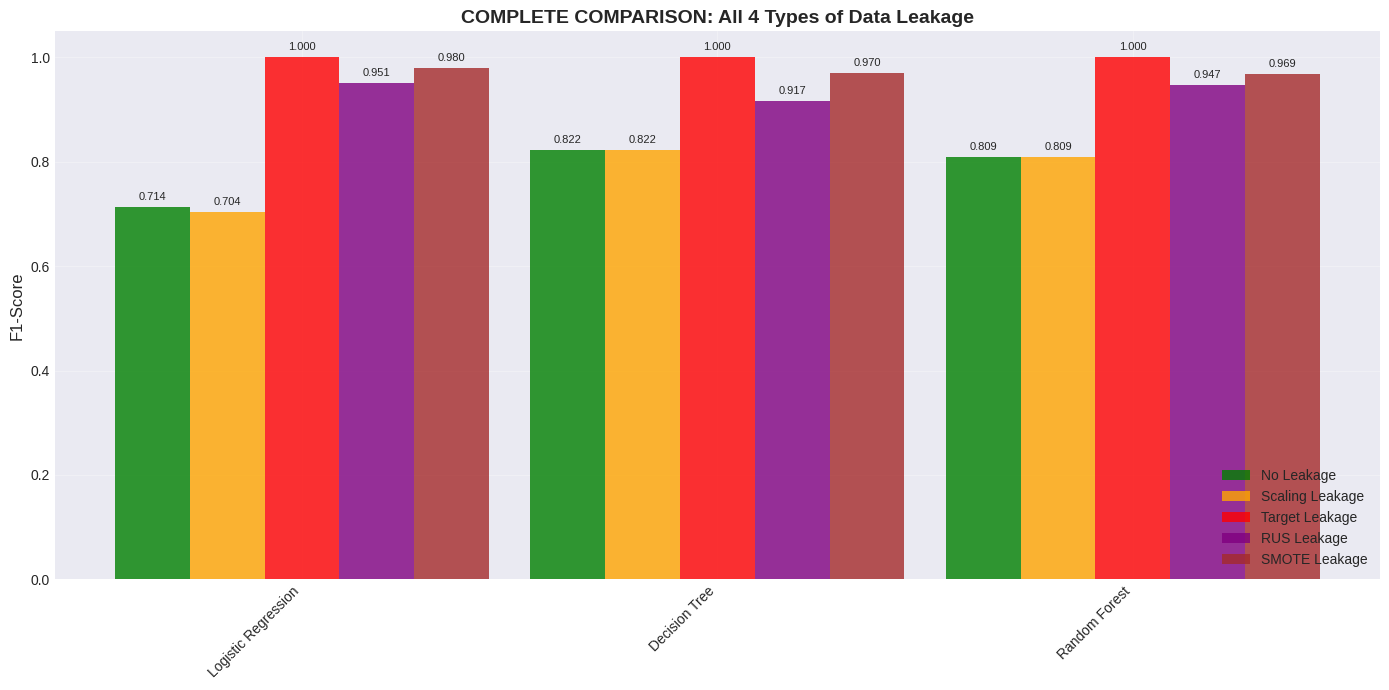

In [16]:
fig, ax = plt.subplots(figsize=(14, 7))

x_pos = np.arange(len([c for c in classifiers.keys() if c != 'SVM']))
width = 0.18
classifier_names = [c for c in classifiers.keys() if c != 'SVM']

leakage_types = ['No Leakage', 'Scaling Leakage', 'Target Leakage', 'RUS Leakage', 'SMOTE Leakage']
colors = ['green', 'orange', 'red', 'purple', 'brown']

for i, (leak_type, color) in enumerate(zip(leakage_types, colors)):
    offset = (i - 2) * width
    if leak_type == 'No Leakage':
        scores = [results_correct_scaling[name]['F1-Score'] for name in classifier_names]
    elif leak_type == 'Scaling Leakage':
        scores = [results_leaky_scaling[name]['F1-Score'] for name in classifier_names]
    elif leak_type == 'Target Leakage':
        scores = [results_target_leakage[name]['F1-Score'] for name in classifier_names]
    elif leak_type == 'RUS Leakage':
        scores = [results_rus_leaky[name]['F1-Score'] for name in classifier_names]
    else:  # SMOTE Leakage
        scores = [results_smote_leaky[name]['F1-Score'] for name in classifier_names]
    
    bars = ax.bar(x_pos + offset, scores, width, label=leak_type, alpha=0.8, color=color)
    
    # Add value labels
    for bar, score in zip(bars, scores):
        if score > 0:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                   f'{score:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('COMPLETE COMPARISON: All 4 Types of Data Leakage', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(classifier_names, rotation=45, ha='right')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()